In [22]:
import matplotlib.pyplot as plt
import pandas as pd
from src import baseClasses, systemClasses, sensorClasses, muxClasses
import datetime
import numpy as np
from tqdm import tqdm

In [ ]:
dataset = baseClasses.Data()

In [4]:
dataset.data = dataset.data.loc[(dataset.data.index > datetime.datetime(2024, 4, 30))&(dataset.data.index < datetime.datetime(2024, 5, 15))]
dataset.err = dataset.err.loc[(dataset.err.index > datetime.datetime(2024, 4, 30))&(dataset.err.index < datetime.datetime(2024, 5, 15))]

In [5]:
tgrad = systemClasses.System(dataset=dataset, name="TGRAD")

Initializing Sensors: 100%|██████████| 48/48 [00:03<00:00, 13.61sensor/s]


In [63]:
tgrad.calibrate(calibName="SECOND_POFF_TGRAD_HAWAI_APA_CE_OFF_REC_OFF_HV_OFF_20241203_132500_20241203_142500", equalizationSumName="TEST")

Equalizing Sensors: 100%|██████████| 48/48 [00:05<00:00,  9.06sensor/s]
Calibrating Sensors - Calibration Name: SECOND_POFF_TGRAD_HAWAI_APA_CE_OFF_REC_OFF_HV_OFF_20241203_132500_20241203_142500: 100%|██████████| 48/48 [00:00<00:00, 85.62sensor/s]


In [64]:
mux1 = muxClasses.MUX(dataset=dataset, boardNumber=1)
mux2 = muxClasses.MUX(dataset=dataset, boardNumber=2)

(1.001, 1.00125)

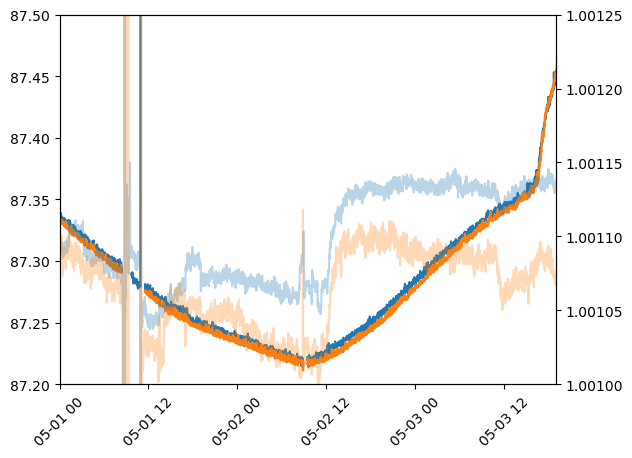

In [65]:
fig, axes = plt.subplots(1,1)
axes.plot(tgrad.sensors[39651].data)
axes.plot(tgrad.sensors[39630].data)
# axes.plot(tgrad.sensors[39644].data - tgrad.sensors[39630].data)
axes.set_ylim(87.2, 87.5)
axes.set_xlim(datetime.datetime(2024, 5, 1, 0, 0, 0), datetime.datetime(2024, 5, 3, 19, 0, 0))
plt.xticks(rotation=45)
axes2 = axes.twinx()
axes2.plot(mux1.data, alpha=0.3)
axes2.plot(mux2.data, alpha=0.3)
axes2.set_ylim(1.001, 1.00125)

In [76]:
tref = datetime.datetime(2024, 5, 2, 10, 10, 0)
h, temp = [], []
for id, sensor in tqdm(tgrad.sensors.items(), desc="Processing Sensors", unit="sensor"):
    h.append(sensor.Y)
    tfin = tref + datetime.timedelta(minutes=10)
    temp_data = sensor.data.loc[(sensor.data.index > tref) & (sensor.data.index < tfin)]
    temp.append(temp_data.mean() if not temp_data.empty else None)  # Avoids NaN issues

Processing Sensors: 100%|██████████| 48/48 [00:00<00:00, 445.45sensor/s]


[7385.0, 7267.0, 7149.0, 7031.0, 6913.0, 6795.0, 6677.0, 6559.0, 6441.0, 6323.0, 6205.0, 6087.0, 5969.0, 5851.0, 5733.0, 5615.0, 5497.0, 5379.0, 5143.0, 4907.0, 4671.0, 4435.0, 4199.0, 3963.0, 3727.0, 3491.0, 3255.0, 3019.0, 2783.0, 2547.0, 2311.0, 2193.0, 2075.0, 1957.0, 1839.0, 1721.0, 1603.0, 1485.0, 1367.0, 1249.0, 1131.0, 1013.0, 895.0, 777.0, 659.0, 541.0, 423.0, 305.0] [87.22041416555349, 87.21283329447694, 87.2175432645667, 87.21690282075413, 87.21841109439067, 87.21952233169009, 87.21283573622756, 87.21999789393875, 87.2201115109311, 87.21920312845474, 87.21820405000335, 87.2188373414474, 87.21921670097464, 87.22005786668228, 87.21922505920338, 87.21660564644836, 87.21712567478285, 87.22016018326939, 87.21511468231259, 87.21557050274279, 87.21680842053462, 87.21728260256941, 87.21743944967608, 87.21906905065671, 87.21703487807319, 87.21632098634106, 87.21924238377508, 87.21916735826393, 87.21863387848286, 87.22336856386002, 87.21745750601076, 87.21974138689863, 87.218093308472

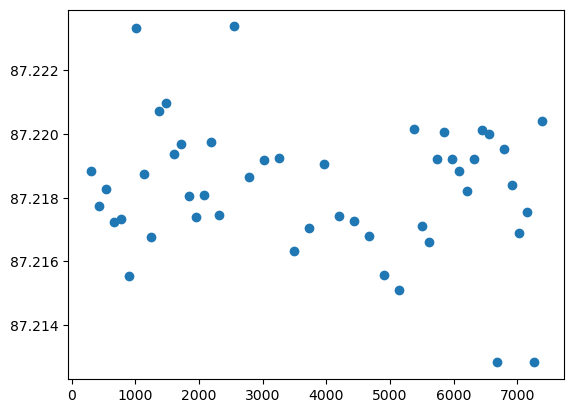

In [77]:
print(h, temp)
plt.plot(h, temp, 'o')

In [62]:
import pickle
test = {1:0, 2:-1.5, 3:0, 4:0}
with open("/eos/user/j/jcapotor/RTDdata/corrections/equalisation_test.pkl", "wb") as f:
    pickle.dump(test, f)